In [ ]:
# ============================================================
# Soft-Voting Ensemble ONLY
# Sultana, Rahman & Hussain (ICCIT 2024)
# Bangla-English Code-Mixed SMS: Spam vs Ham
# ============================================================
import re, numpy as np, pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

RANDOM_STATE = 42

In [ ]:
# ============================================================
# LOAD & MERGE THE THREE DATASETS  (binary: spam vs ham)
#   Downloaded from the HF Hub dataset repo:
#     https://huggingface.co/datasets/shariul-islam/simulation2_dataset
#   spam.csv             = TAB-delimited  (English / UCI SMS Spam Collection)
#   bangla_spam_sms.csv  = COMMA-delimited (Bangla)
#   code_mixed_sms.csv   = COMMA-delimited (Bangla-English code-mixed)
#   All headerless: label in column 0, text in column 1.
# ============================================================
from huggingface_hub import hf_hub_download

HF_DATASET_REPO = "shariul-islam/simulation2_dataset"

def _hf_csv(filename):
    return hf_hub_download(repo_id=HF_DATASET_REPO, filename=filename,
                           repo_type="dataset")

spam_path = _hf_csv("spam.csv")
bn_path   = _hf_csv("bangla_spam_sms.csv")
cm_path   = _hf_csv("code_mixed_sms.csv")

en = pd.read_csv(spam_path, sep="\t", header=None,
                 names=["label", "text"], encoding="latin-1",
                 quoting=3)   # QUOTE_NONE
bn = pd.read_csv(bn_path, header=None,
                 names=["label", "text"], encoding="utf-8")
cm = pd.read_csv(cm_path, header=None,
                 names=["label", "text"], encoding="utf-8")

def norm_label(x):
    return "spam" if str(x).strip().lower() == "spam" else "ham"

frames = []
for d in (en, bn, cm):
    d = d.copy()
    d["label"] = d["label"].map(norm_label)
    d["text"]  = d["text"].astype(str)
    frames.append(d[["text", "label"]])

df = (pd.concat(frames, ignore_index=True)
        .dropna()
        .drop_duplicates("text")
        .reset_index(drop=True))

print("Merged dataset:", df.shape)
print(df["label"].value_counts())
print("\nPer-source counts:")
for name, d in [("English", en), ("Bangla", bn), ("Code-mixed", cm)]:
    print(f"  {name:11s}: {len(d):5d}")

spam.csv:   0%|          | 0.00/478k [00:00<?, ?B/s]

bangla_spam_sms.csv:   0%|          | 0.00/112k [00:00<?, ?B/s]

code_mixed_sms.csv:   0%|          | 0.00/78.4k [00:00<?, ?B/s]

Merged dataset: (6150, 2)
label
ham     4961
spam    1189
Name: count, dtype: int64

Per-source counts:
  English    :  5574
  Bangla     :   504
  Code-mixed :   500


In [ ]:
# ============================================================
# 2. PREPROCESSING  (Sec III.B)
# ============================================================
BANGLA_NUMERALS = "০১২৩৪৫৬৭৮৯"
_num_re   = re.compile(f"[{BANGLA_NUMERALS}]")
_punct_re = re.compile(r"""['"“”‘’.?!,…:;()\[\]{}$%&+=*/\\|<>@#^~`।_-]""")
_ws_re    = re.compile(r"\s+")

def clean_text(s: str) -> str:
    s = _punct_re.sub(" ", s)      # punctuation removal
    s = _num_re.sub(" ", s)        # Bangla numeral removal
    s = _ws_re.sub(" ", s).strip() # whitespace normalization
    return s

df["clean"] = df["text"].map(clean_text)
y = (df["label"] == "spam").astype(int).values   # spam=1, ham=0

In [ ]:
# ============================================================
# 3. TF-IDF + 80/20 SPLIT  (Sec III.C, IV.B)
# ============================================================
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df["clean"])

Xtr, Xte, ytr, yte = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)

In [ ]:
# ============================================================
# 4. SOFT-VOTING ENSEMBLE  (Algorithm 1)
# ============================================================
ensemble = VotingClassifier(
    estimators=[
        ("lr",   LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
        ("rf",   RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)),
        ("mlpc", MLPClassifier(hidden_layer_sizes=(100,), max_iter=400, random_state=RANDOM_STATE)),
        ("svm",  SVC(probability=True, random_state=RANDOM_STATE)),
    ],
    voting="soft")

ensemble.fit(Xtr, ytr)
pred = ensemble.predict(Xte)

Accuracy : 97.97%
Precision: 0.98
Recall   : 0.98
F1-Score : 0.98

Classification report
              precision    recall  f1-score   support

         ham     0.9792    0.9960    0.9875       992
        spam     0.9819    0.9118    0.9455       238

    accuracy                         0.9797      1230
   macro avg     0.9805    0.9539    0.9665      1230
weighted avg     0.9797    0.9797    0.9794      1230



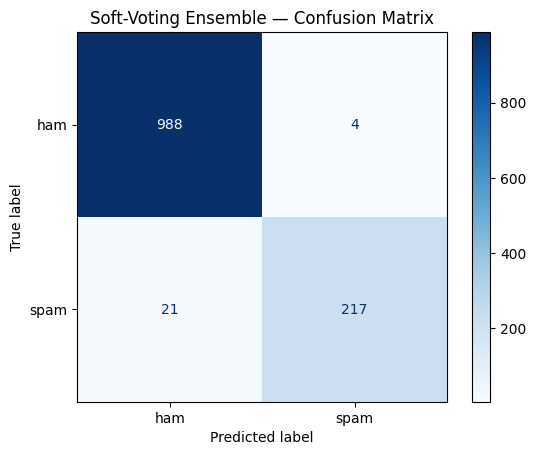

In [ ]:
# ============================================================
# 5. RESULTS
# ============================================================
print("Accuracy : %.2f%%" % (accuracy_score(yte, pred)*100))
print("Precision: %.2f"   %  precision_score(yte, pred, average="weighted"))
print("Recall   : %.2f"   %  recall_score(yte, pred, average="weighted"))
print("F1-Score : %.2f"   %  f1_score(yte, pred, average="weighted"))

print("\nClassification report")
print(classification_report(yte, pred, target_names=["ham","spam"], digits=4))

cm = confusion_matrix(yte, pred)
ConfusionMatrixDisplay(cm, display_labels=["ham","spam"]).plot(cmap="Blues")
plt.title("Soft-Voting Ensemble — Confusion Matrix")
plt.show()